In [44]:
import numpy as np
import pandas as pd
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 

from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import MinMaxScaler, StandardScaler

def adf_test(series, title=""):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f"Augmented Dickey-Fuller Test: {title}")
    result = adfuller(
        series.dropna(), autolag="AIC"
    )  # .dropna() handles differenced data

    labels = ["ADF test statistic", "p-value", "# lags used", "# observations"]
    out = pd.Series(result[0:4], index=labels)

    for key, val in result[4].items():
        out[f"critical value ({key})"] = val

    print(out.to_string())  # .to_string() removes the line "dtype: float64"

    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

def total_mean_error(predictions):
    mean_error = []

    for i in range(len(predictions)):
        if df['Normalized'][i] == 0:
            error_value = np.abs((predictions[i]-0.01)/(0.01))*100
            mean_error.append(error_value)
            print(
                f"predição={predictions[i]}, esperado={df['Normalized'][i]}, erro={error_value}%"
            )
        else:
            error_value = np.abs((predictions[i]-df['Normalized'][i])/(df['Normalized'][i]))*100
            mean_error.append(error_value)
            print(
                f"predição={predictions[i]}, esperado={df['Normalized'][i]}, erro={error_value}%"
            )

    aux = 0

    for i in range(len(mean_error)):
        if mean_error[i] > 200:
            aux = aux
        else:
            aux = mean_error[i] + aux

    final_mean = aux/len(mean_error)

    print(f"Erro percentual médio = {final_mean}%")

In [45]:
# Lendo os dados
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico-main/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"
df

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
2019-11-01,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01,2854.0,7440.0,280.0,1200.0,2480.0


In [46]:
df = pd.concat([df, df])
with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.precision",
    3,
):
    print(df)

           3003858507 3001084033 3011373971 3001449459 3011504476
idx                                                              
2019-06-01     1246.0     7160.0      440.0      960.0     1560.0
2019-07-01     1081.0     6520.0      600.0      920.0     1280.0
2019-08-01     1184.0     6840.0      680.0     1120.0     1360.0
2019-09-01     1549.0     7440.0      760.0     1040.0     1680.0
2019-10-01     2045.0     6920.0      560.0     1120.0     1680.0
2019-11-01     4017.0     6920.0      520.0     1240.0     2920.0
2019-12-01     2386.0     7240.0      320.0     1000.0     1960.0
2020-01-01     4239.0     6560.0      440.0     1120.0     2280.0
2020-02-01     2854.0     7440.0      280.0     1200.0     2480.0
2020-03-01     3208.0     7440.0      320.0     1360.0     2240.0
2020-04-01     1048.0     5640.0      440.0     1080.0     1480.0
2020-05-01     1313.0     4880.0        0.0     1040.0     1280.0
2020-06-01     1174.0     5080.0        0.0     1320.0     1240.0
2020-07-01

In [47]:
new_index = pd.date_range(start=df.index.min(), periods=len(df), freq="MS")

df.index = new_index

df

,3003858507,3001084033,3011373971,3001449459,3011504476
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
...,...,...,...,...,...
2026-07-01,1216.0,7440.0,920.0,1000.0,2280.0
2026-08-01,1335.0,7240.0,360.0,840.0,2000.0
2026-09-01,1317.0,7960.0,680.0,880.0,2160.0
2026-10-01,2367.0,5880.0,800.0,840.0,2120.0


In [48]:
values = df[3003858507].values
values = values.reshape((len(values), 1))

scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(values)

df_normalized = scaler.transform(values)
for i in range(5):
    print(df_normalized[i])

[0.17729522]
[0.13194063]
[0.16025289]
[0.26058274]
[0.39692139]


In [49]:
df["Normalized"] = df_normalized

In [50]:
auto_arima(
    df["Normalized"],
    m=12,
    seasonal=True,
).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   90
Model:             SARIMAX(3, 0, 1)x(0, 0, 1, 12)   Log Likelihood                  14.041
Date:                            Thu, 29 Feb 2024   AIC                            -14.081
Time:                                    16:07:50   BIC                              3.417
Sample:                                06-01-2019   HQIC                            -7.025
                                     - 11-01-2026                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0789      0.021      3.704      0.000       0.037       0.121
ar.L1          1.3863      0.103     13.489      0.000       1.185       1.588
ar.L2         -0.3253      0.167     -1.942      0.052      -0.654       0.003
ar.L3         -0.2436      0.111     -2.189      0.029      -0.462      -0.025
ma.L1         -0.9633      0.078    -12.279      0.000      -1.117      -0.810
ma.S.L12       0.0655      0.188      0.349      0.727      -0.303       0.434
sigma2         0.0412      0.007      5.725      0.000       0.027       0.055
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.58
Prob(Q):                              0.98   Prob(JB):                         0.45
Heteroskedasticity (H):               0.81   Skew:                             0.32
Prob(H) (two-sided):                  0.56   Kurtosis:                         3.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [51]:
train = df.iloc[:80]
test = df.iloc[80:]

test = test.astype(float)
train = train.astype(float)

model = SARIMAX(train["Normalized"], order=(3, 0, 1), seasonal_order=(5, 1, 1, 12))
results = model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           11     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.10095D-01    |proj g|=  2.70684D-01


 This problem is unconstrained.



At iterate    5    f=  8.71137D-02    |proj g|=  3.85821D-02

At iterate   10    f=  8.07004D-02    |proj g|=  1.62369D-02

At iterate   15    f=  7.18349D-02    |proj g|=  4.71130D-02

At iterate   20    f=  5.70322D-02    |proj g|=  1.83924D-01

At iterate   25    f=  5.47410D-02    |proj g|=  2.17059D-02

At iterate   30    f=  5.28401D-02    |proj g|=  5.53869D-02

At iterate   35    f=  5.16050D-02    |proj g|=  2.49099D-02

At iterate   40    f=  5.09493D-02    |proj g|=  3.80181D-02

At iterate   45    f=  5.00694D-02    |proj g|=  1.75152D-02

At iterate   50    f=  4.98124D-02    |proj g|=  8.86242D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

In [52]:
start = len(train)
end = len(train) + len(test) - 1
normalized_predictions = results.predict(
    start=0, end=end, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

normalized_future_predictions = results.predict(
    start=end, end=end + 44, dynamic=False, typ="levels"
).rename("SARIMA Future Predictions")

total_mean_error(normalized_predictions)

predição=0.0, esperado=0.1772952171522815, erro=100.0%
predição=2.0117935176365965e-08, esperado=0.13194062671797693, erro=99.99998475228163%
predição=3.03703708890893e-08, esperado=0.16025288620120945, erro=99.99998104847182%
predição=3.6799883834482544e-08, esperado=0.26058273776800445, erro=99.99998587785049%
predição=4.9562886299277124e-08, esperado=0.3969213853765806, erro=99.99998751317311%
predição=6.963201307523428e-08, esperado=0.9389774601429358, erro=99.99999258427215%
predição=1.3911372842630226e-07, esperado=0.49065420560747663, erro=99.99997164729726%
predição=1.3059771514034824e-07, esperado=1.0, erro=99.9999869402285%
predição=1.5681473962699467e-07, esperado=0.6192963166575042, erro=99.9999746785609%
predição=1.2025828739382304e-07, esperado=0.7166025288620121, erro=99.99998321827196%
predição=7.457357238569089e-08, esperado=0.12286970863111599, erro=99.99993930678829%
predição=-4.127622504499675e-08, esperado=0.19571192963166575, erro=100.00002109029589%
predição=0.17

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

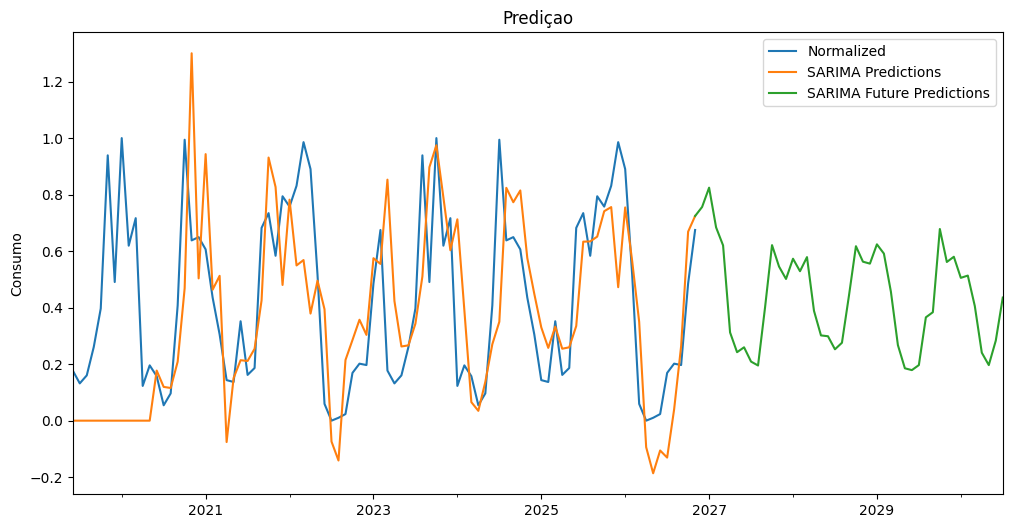

In [53]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df["Normalized"].plot(legend=True, figsize=(12, 6), title=title)
normalized_predictions.plot(legend=True)
normalized_future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)